<a href="https://colab.research.google.com/github/phantrinhquocbao/Do_An_2/blob/main/ch%C6%B0%C6%A1ng%20tr%C3%ACnh%20hu%E1%BA%A5n%20luy%C3%AAn%20AI%20tr%C3%AAn%20Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- BƯỚC 1: TẢI DỮ LIỆU LỊCH SỬ (2019 - 2024) ---


YF.download() has changed argument auto_adjust default to True
Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


--- BƯỚC 2: CHUẨN HÓA VÀ LƯU PHỄU LỌC ---
--- BƯỚC 3: CẮT DỮ LIỆU CHO LSTM ---
--- BƯỚC 4: XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH ---
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0579 - val_loss: 0.0033
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0065 - val_loss: 0.0028
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0053 - val_loss: 0.0014
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0042 - val_loss: 6.9078e-04
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0034 - val_loss: 8.2409e-04
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0035 - val_loss: 6.7435e-04
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0035 - val_loss: 0.0014
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0039 - val_loss: 6.5473e-04
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0029 - val_loss: 6.5876e-04
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0026 - val_loss: 6.6655e-04

--- BƯỚC 5: LƯU MÔ HÌNH ---
✅ THÀNH CÔNG! Fen nhìn sang cột File bên trái của Colab để tải 2 file về máy tính nha!


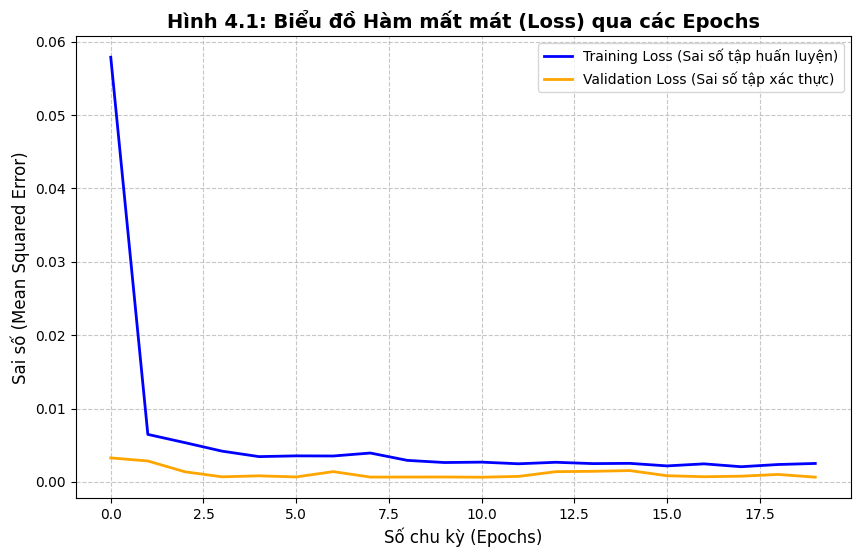

In [ ]:
# 1. Cài đặt thư viện trước
!pip install vnstock==0.2.9.2 yfinance scikit-learn

import pandas as pd
import numpy as np
import yfinance as yf
from vnstock import stock_historical_data
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import joblib

# --- THÔNG SỐ CƠ BẢN ---
TIME_STEPS = 60
FEATURES = ['Open_VN', 'High_VN', 'Low_VN', 'Close_VN', 'Volume_VN', 'Close_US']
TARGET_INDEX = 3 # Vị trí cột 'Close_VN' (Bắt đầu đếm từ 0)

print("--- BƯỚC 1: TẢI DỮ LIỆU LỊCH SỬ (2019 - 2024) ---")
# Lấy HPG
df_vn = stock_historical_data(symbol='HPG', start_date='2019-01-01', end_date='2024-01-01', resolution='1D', type='stock')
df_vn = df_vn[['time', 'open', 'high', 'low', 'close', 'volume']]
df_vn.columns = ['Date', 'Open_VN', 'High_VN', 'Low_VN', 'Close_VN', 'Volume_VN']
df_vn['Date'] = pd.to_datetime(df_vn['Date'])

# Lấy S&P 500
df_qt = yf.download('^GSPC', start='2019-01-01', end='2024-01-01', progress=False)
if isinstance(df_qt.columns, pd.MultiIndex):
    df_qt = df_qt['Close'].reset_index()
else:
    df_qt = df_qt[['Close']].reset_index()
df_qt.columns = ['Date', 'Close_US']
df_qt['Date'] = pd.to_datetime(df_qt['Date']).dt.tz_localize(None)

# Gộp dữ liệu
df_merged = pd.merge(df_vn, df_qt, on='Date', how='inner').ffill()
data = df_merged[FEATURES].values

print("--- BƯỚC 2: CHUẨN HÓA VÀ LƯU PHỄU LỌC ---")
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
joblib.dump(scaler, 'scaler.pkl')

print("--- BƯỚC 3: CẮT DỮ LIỆU CHO LSTM ---")
X, y = [], []
for i in range(TIME_STEPS, len(scaled_data)):
    X.append(scaled_data[i-TIME_STEPS:i, :])
    y.append(scaled_data[i, TARGET_INDEX])
X, y = np.array(X), np.array(y)

print("--- BƯỚC 4: XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH ---")
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# SỬA Ở ĐÂY: Thêm biến history = ... và thêm validation_split=0.2
history = model.fit(X, y, batch_size=32, epochs=20, validation_split=0.2)

print("--- BƯỚC 5: LƯU MÔ HÌNH ---")
model.save('lstm_vn30_model.h5')
print("✅ THÀNH CÔNG!")

import matplotlib.pyplot as plt

# Kích thước biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ 2 đường loss
plt.plot(history.history['loss'], color='blue', linewidth=2, label='Training Loss (Sai số tập huấn luyện)')
plt.plot(history.history['val_loss'], color='orange', linewidth=2, label='Validation Loss (Sai số tập xác thực)')

# Trang trí biểu đồ
plt.title('Hình 4.1: Biểu đồ Hàm mất mát (Loss) qua các Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Số chu kỳ (Epochs)', fontsize=12)
plt.ylabel('Sai số (Mean Squared Error)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Lưu thành file ảnh và hiển thị
plt.savefig('hinh_4_1_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

--- BƯỚC 6: DỰ BÁO VÀ VẼ BIỂU ĐỒ SO SÁNH (HÌNH 4.2) ---
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


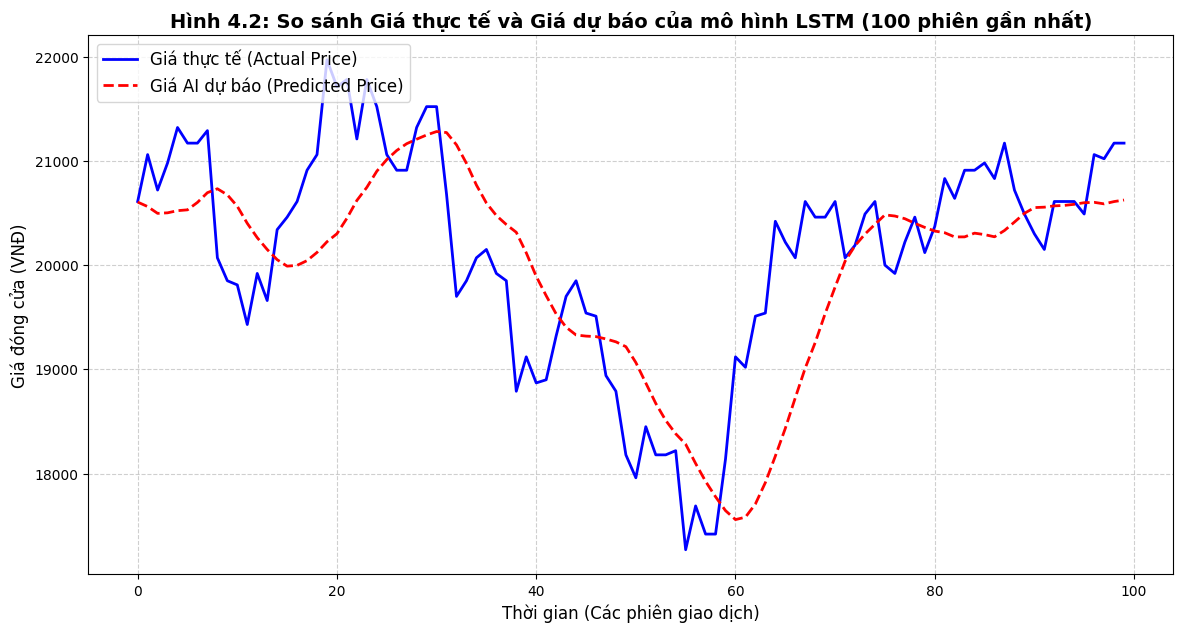

✅ LƯU ẢNH THÀNH CÔNG! File 'hinh_4_2_price_comparison.png' đã sẵn sàng để dán vào báo cáo!


In [ ]:
print("--- BƯỚC 6: DỰ BÁO VÀ VẼ BIỂU ĐỒ SO SÁNH (HÌNH 4.2) ---")
# 1. Cho AI dự báo trên tập X hiện tại
predicted_prices_scaled = model.predict(X)

# 2. Khôi phục giá trị thực (Inverse Transform) từ [0, 1] về VNĐ
# Tạo ma trận tạm 6 cột để khớp với cấu trúc của scaler
predict_extended = np.zeros((len(predicted_prices_scaled), len(FEATURES)))
predict_extended[:, TARGET_INDEX] = predicted_prices_scaled[:, 0]
predicted_prices = scaler.inverse_transform(predict_extended)[:, TARGET_INDEX]

# Làm tương tự để khôi phục mệnh giá thực tế của y (để có cái so sánh)
y_extended = np.zeros((len(y), len(FEATURES)))
y_extended[:, TARGET_INDEX] = y
actual_prices = scaler.inverse_transform(y_extended)[:, TARGET_INDEX]

# 3. Vẽ biểu đồ (Chỉ lấy 100 phiên giao dịch cuối cùng cho biểu đồ bớt nén, dễ nhìn)
zoom = 100

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Vẽ đường giá thực tế (Actual) màu xanh
plt.plot(actual_prices[-zoom:], color='blue', label='Giá thực tế (Actual Price)', linewidth=2)
# Vẽ đường giá dự báo (Predicted) màu đỏ nét đứt
plt.plot(predicted_prices[-zoom:], color='red', label='Giá AI dự báo (Predicted Price)', linewidth=2, linestyle='--')

# Trang trí biểu đồ cho xịn sò
plt.title('Hình 4.2: So sánh Giá thực tế và Giá dự báo của mô hình LSTM (100 phiên gần nhất)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Các phiên giao dịch)', fontsize=12)
plt.ylabel('Giá đóng cửa (VNĐ)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Lưu thành file ảnh và hiển thị
plt.savefig('hinh_4_2_price_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ LƯU ẢNH THÀNH CÔNG! File 'hinh_4_2_price_comparison.png' đã sẵn sàng để dán vào báo cáo!")